<a href="https://colab.research.google.com/github/rameshpolaveni2576/python-basics-assignment/blob/main/Linear_Regression_13thJuly2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
df = pd.read_csv("/content/used_cars_messy.csv")
df

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,2581,Renault Duster,Renault,Duster,7,67647,Dealer,Diesel,Manual,19.87,1461.0,83.80,5.0,575000.0
1,224,Maruti Wagon R,Maruti,Wagon R,3,52000,Dealer,CNG,Manual,33.54,998.0,67.04,5.0,435000.0
2,1803,Honda City,Honda,City,3,48959,Dealer,Petrol,Manual,NaN,1497.0,117.60,5.0,875000.0
3,2728,Mahindra Scorpio,Mahindra,Scorpio,6,82000,dealer,Diesel,Manual,15.4,2179.0,NaN,8.0,925000.0
4,14160,Mahindra XUV500,Mahindra,XUV500,4,34000,Dealer,Diesel,Automatic,16.0,2179.0,140.00,7.0,1175000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,6581,Maruti Ertiga,Maruti,Ertiga,7,127731,Dealer,Diesel,Manual,20.77,1248.0,88.80,7.0,665000.0
15657,17029,Volkswagen Vento,Volkswagen,Vento,11,59000,Dealer,Petrol,Manual,16.09,NaN,103.20,5.0,249000.0
15658,6839,Maruti Wagon R,Maruti,Wagon R,7,20000,Individual,Petrol,Manual,20.51,998.0,67.04,5.0,250000.0
15659,1104,Hyundai i20,Hyundai,i20,2,15000,Dealer,Petrol,Manual,18.6,1197.0,81.86,5.0,620000.0


In [4]:
df.shape

(15661, 14)

In [5]:
cat_cols = ["brand", "seller_type", "fuel_type", "transmission_type"]

for cat in cat_cols:
    unique_vals = df[cat].unique()
    print(f"\n{cat} ({len(unique_vals)} unique Values)")
    print(sorted(unique_vals))


brand (80 unique Values)
[' Audi', ' Audi ', ' BMW', ' BMW ', ' Datsun', ' Datsun ', ' Ferrari ', ' Ford', ' Ford ', ' Honda', ' Honda ', ' Hyundai', ' Hyundai ', ' ISUZU ', ' Land Rover', ' MG ', ' Mahindra', ' Mahindra ', ' Maruti', ' Maruti ', ' Mercedes-AMG ', ' Mercedes-Benz ', ' Mini ', ' Nissan ', ' Porsche', ' Renault', ' Renault ', ' Skoda', ' Skoda ', ' Tata', ' Tata ', ' Toyota', ' Toyota ', ' Volkswagen', ' Volkswagen ', 'Audi', 'Audi ', 'BMW', 'BMW ', 'Bentley', 'Datsun', 'Datsun ', 'Force', 'Ford', 'Ford ', 'Honda', 'Honda ', 'Hyundai', 'Hyundai ', 'ISUZU', 'Isuzu', 'Jaguar', 'Jeep', 'Kia', 'Land Rover', 'Lexus', 'MG', 'Mahindra', 'Mahindra ', 'Maruti', 'Maruti ', 'Maserati', 'Mercedes-Benz', 'Mercedes-Benz ', 'Mini', 'Nissan', 'Porsche', 'Renault', 'Renault ', 'Rolls-Royce', 'Skoda', 'Skoda ', 'Tata', 'Tata ', 'Toyota', 'Toyota ', 'Volkswagen', 'Volkswagen ', 'Volvo', 'Volvo ']

seller_type (9 unique Values)
['DEALER', 'Dealer', 'Delaer', 'Individual', 'Individuall', 'I

In [6]:
df['km_driven'].sample(50).tolist()

['100000',
 '70000',
 '30000',
 '25500',
 '45000',
 '150000',
 '92000',
 '21000',
 '30000',
 '74000',
 '40000',
 '35000',
 '50021',
 '48265',
 '46000',
 '78000',
 '45000',
 '20000',
 '6200',
 '71000',
 '90000',
 '60000',
 '27000',
 '61000',
 '31000',
 '70763',
 '34500',
 '70000',
 '90000',
 '49000',
 '56400',
 '27,599',
 '110000',
 '70000 km',
 '30000',
 '33070',
 '31993',
 '50000',
 '68000',
 '33000',
 '17000',
 '85000',
 '170000',
 '78000',
 '91245',
 '90000 km',
 '47000',
 '45000',
 '52000',
 '57000']

In [7]:
df['mileage'].sample(200).tolist()

['24.04',
 '18.9',
 '16.09',
 '25.6',
 '21.38',
 '22.0',
 '13.5',
 '13.68',
 '18.6',
 '20.36',
 '15.97',
 '16.11',
 '20.0',
 '24.3',
 '9.52',
 '21.79',
 '18.9',
 '25.83',
 '20.73',
 '17.05',
 '17.0',
 '21.79',
 '15.04',
 '20.89',
 '18.5',
 '20.5',
 '18.19',
 '26.59',
 '18.19',
 '18.9',
 '18.16',
 '23.1',
 '15.4',
 '23.95',
 '17.01',
 '20.45',
 '20.51',
 '15.04',
 '17.68',
 '15.1',
 '23.95',
 '19.7',
 '24.3',
 '18.0',
 '17.9',
 '26.0',
 nan,
 '17.4',
 '23.01',
 '19.87',
 nan,
 '22.77',
 nan,
 '21.0',
 '13.0',
 '23.95',
 '14.8',
 '21.79',
 '22.8',
 '18.9',
 '21.66',
 '23.01',
 '22.69',
 '10.0',
 nan,
 '33.54',
 '21.4',
 '23.95',
 '24.52',
 '17.5',
 '11.36',
 nan,
 '26.21',
 '19.7',
 '17.19',
 '16.78',
 '18.9',
 nan,
 '26.21 kmpl',
 '11.5',
 '23.4',
 '16.36',
 '19.87',
 '20.36',
 nan,
 '15.96',
 nan,
 '15.4',
 '14.28',
 '24.7',
 '15.1 kmpl',
 '21.38',
 '21.4',
 '25.83',
 '22.74',
 '21.4',
 '27.39',
 '18.9',
 '23.01',
 '20.36',
 '9.52',
 '18.9',
 nan,
 '21.01',
 '20.0',
 '28.4',
 '18.6',
 

In [8]:
pd.set_option('display.float_format', '{:.4f}'.format)

In [9]:
df['selling_price'].describe()

,selling_price
count,15503.0000
mean,1032763.7793
std,16073797.4950
min,500.0000
25%,385000.0000
50%,555000.0000
75%,825000.0000
max,999999999.0000


In [10]:
df = df.drop(columns = ['Unnamed: 0'])
df.columns

Index(['car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type',
       'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power',
       'seats', 'selling_price'],
      dtype='object')

In [11]:
print(f"Unique values before cleaning {df['brand'].nunique()}")

df['brand'] = df['brand'].str.strip()

print(f"Unique values After cleaning {df['brand'].nunique()}")

df['brand'].value_counts().head(10)

Unique values before cleaning 80
Unique values After cleaning 32


,count
brand,
Maruti,5077
Hyundai,3025
Honda,1508
Mahindra,1031
Toyota,806
Ford,802
Volkswagen,634
Renault,550
BMW,443


In [12]:
print(f"Unique values before cleaning {df['fuel_type'].nunique()}")
df['fuel_type'] = df['fuel_type'].str.strip().str.title()
print(f"Unique values after cleaning {df['fuel_type'].nunique()}")
df['fuel_type'].value_counts().head(10)

Unique values before cleaning 14
Unique values after cleaning 5


,count
fuel_type,
Petrol,7765
Diesel,7544
Cng,302
Lpg,46
Electric,4


In [13]:
print(f"Unique values before cleaning {df['seller_type'].nunique()}")

df['seller_type'] = df['seller_type'].str.strip().str.title()

print(f"Unique values after cleaning {df['seller_type'].nunique()}")

# Create a dictiorny

# Step 2: Fix remaining typos with a mapping
typo_map = {
    'Individul': 'Individual',
    'Individuall': 'Individual',
    'Delaer': 'Dealer',
    'Trustmark Delaer': 'Trustmark Dealer'
}

df['seller_type'] = df['seller_type'].replace(typo_map)
print(f"Final Unique values after cleaning {df['seller_type'].nunique()}")
print(df['seller_type'].value_counts())

Unique values before cleaning 9
Unique values after cleaning 6
Final Unique values after cleaning 3
seller_type
Dealer              9694
Individual          5792
Trustmark Dealer     175
Name: count, dtype: int64


In [14]:
df['km_driven'].sample(100).tolist()

['50287',
 '15000',
 '70000',
 '68219',
 '70000',
 '58200',
 '20000',
 '55000',
 '20000',
 '99000',
 '43000',
 '27648',
 '24000',
 '56000',
 '46000',
 '5000',
 '17000',
 '30000',
 '100000',
 '58000',
 '28500',
 '35000',
 '33000',
 '75000',
 '44000',
 '10000',
 '19955',
 '30000',
 '50205',
 '68128',
 '37000',
 '67235',
 '8000',
 '60000',
 '60000',
 '111000',
 '85000',
 '96000',
 '60000',
 '24024',
 '79431',
 '62600',
 '89000',
 '40000',
 '80000',
 '40000',
 '10000',
 '38000',
 '110000',
 '62000',
 '25000',
 '31500',
 '55000',
 '71000',
 '70000',
 '15000',
 '8000',
 '15000',
 '24000',
 '70000',
 '80000',
 '277000',
 '33000',
 '17000',
 '65000',
 '60000',
 '30000',
 '148000',
 '20000',
 '73000',
 '15000',
 '142000',
 '112000',
 '80000',
 '61000',
 '31200',
 '70000',
 '4269',
 '92000',
 '60000',
 '71000',
 '60000',
 '41000',
 '89005',
 '66475',
 '48000',
 '110000',
 '30000',
 '80633',
 '25000',
 '17550',
 '9000',
 '26000',
 '90000',
 '60000',
 '10002',
 '76000',
 '40000',
 '90000',
 '60000

In [15]:
df['km_driven'] = df['km_driven'].astype(str)
df['km_driven'] = df['km_driven'].str.replace(",", "")
df['km_driven'] = df['km_driven'].str.replace("kms", "")
df['km_driven'] = df['km_driven'].str.replace("km", "")
df['km_driven'] = df['km_driven'].str.strip()
df['km_driven'] = pd.to_numeric(df['km_driven'], errors = 'coerce')
df['km_driven'].sample(100)

,km_driven
15489,130890
4844,68000
1894,140000
13121,25000
3916,14000
...,...
3217,66600
374,33000
6248,30000
2862,18000


In [16]:
df['mileage'] = df['mileage'].astype(str).replace("kmpl", "")
df['mileage'] = df['mileage'].str.strip()
df['mileage'] = pd.to_numeric(df['mileage'], errors = 'coerce')
df['mileage'].sample(100)

,mileage
903,25.5000
503,21.2100
9595,16.1000
5460,16.4700
13355,18.9000
...,...
11173,NaN
14934,12.6500
9361,24.0400
7926,18.2700


In [17]:
df.loc[3,"km_driven"]

np.int64(82000)

In [18]:
df.isnull().sum()

,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,1485
engine,1869


In [19]:
before = len(df)

df = df.dropna(subset=['selling_price'])
after = len(df)

print(f"Dropped {before -after} rows where selling_price was missing")
print(f"remaining rows {after}")

Dropped 158 rows where selling_price was missing
remaining rows 15503


In [20]:
for col in ["engine", "mileage", "max_power"]:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"filled {col} missing vlaues with median: {median_val}")

filled engine missing vlaues with median: 1248.0
filled mileage missing vlaues with median: 19.67
filled max_power missing vlaues with median: 88.5


In [21]:
seats_mode = df['seats'].mode()[0]
df["seats"] = df["seats"].fillna(seats_mode)
print(f"filled seats missing vlaues with mode: {seats_mode}")

filled seats missing vlaues with mode: 5.0


In [22]:
df = df.drop_duplicates()

In [23]:
df.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15212.0000,15212.0000,15212.0000,15212.0000,15212.0000,15212.0000,15212.0000
mean,6.0379,55611.7656,19.6858,1452.9972,99.9624,5.3151,1038508.0115
std,3.0161,51839.7243,3.9685,486.3077,41.8938,0.7972,16226444.0022
min,0.0000,100.0000,4.0000,793.0000,38.4000,0.0000,500.0000
25%,4.0000,30000.0000,17.1000,1197.0000,74.0000,5.0000,385000.0000
50%,6.0000,50000.0000,19.6700,1248.0000,88.5000,5.0000,555000.0000
75%,8.0000,70000.0000,22.3000,1498.0000,113.4200,5.0000,825000.0000
max,29.0000,3800000.0000,33.5400,6592.0000,626.0000,9.0000,999999999.0000


Text(0, 0.5, 'Price (₹)')

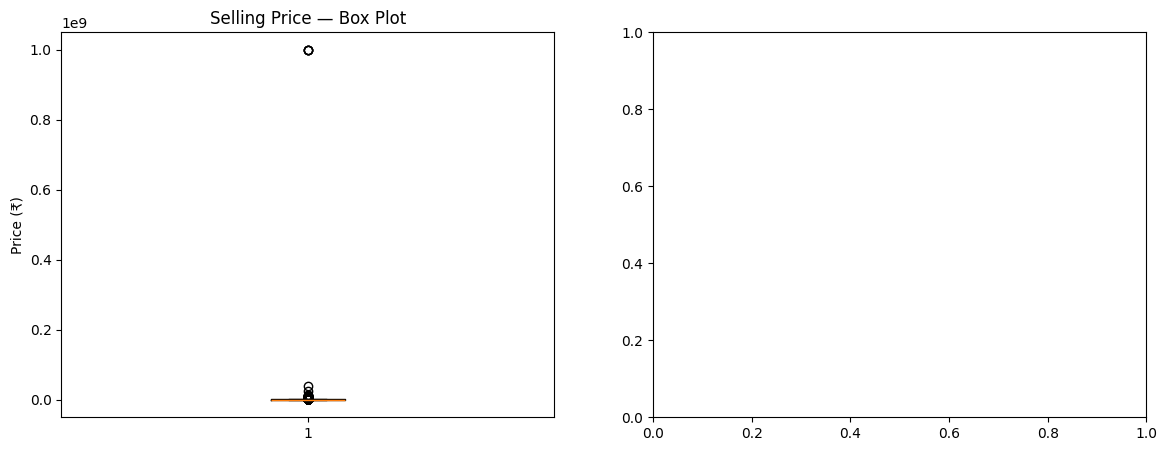

In [24]:
# Visualize outliers in selling_price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
axes[0].boxplot(df['selling_price'].dropna(), vert=True)
axes[0].set_title('Selling Price — Box Plot')
axes[0].set_ylabel('Price (₹)')

In [25]:
before = len(df)

df = df[df['selling_price'] != 999999999]
df = df[df["selling_price"]>10000]
df = df[df["seats"]>0]

after = len(df)


print(before, after)

15212 15202


In [26]:
df[df['vehicle_age'] == '15152']

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price


In [27]:
# Method 1: Simple map (recommended for binary)
df['transmission_type'] = df['transmission_type'].map({'Manual': 0, 'Automatic': 1})

df['transmission_type']

,transmission_type
0,0
1,0
2,0
3,0
4,1
...,...
15656,0
15657,0
15658,0
15659,0


In [28]:
print(f"Number of columns beofre one hot encoding {df.shape[1]}")

df = pd.get_dummies(df, columns = ['fuel_type', 'seller_type'], drop_first = True)

print(f"Number of columns after one hot encoding {df.shape[1]}")

df

Number of columns beofre one hot encoding 13
Number of columns after one hot encoding 17


,car_name,brand,model,vehicle_age,km_driven,transmission_type,mileage,engine,max_power,seats,selling_price,fuel_type_Diesel,fuel_type_Electric,fuel_type_Lpg,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer
0,Renault Duster,Renault,Duster,7,67647,0,19.8700,1461.0000,83.8000,5.0000,575000.0000,True,False,False,False,False,False
1,Maruti Wagon R,Maruti,Wagon R,3,52000,0,33.5400,998.0000,67.0400,5.0000,435000.0000,False,False,False,False,False,False
2,Honda City,Honda,City,3,48959,0,19.6700,1497.0000,117.6000,5.0000,875000.0000,False,False,False,True,False,False
3,Mahindra Scorpio,Mahindra,Scorpio,6,82000,0,15.4000,2179.0000,88.5000,8.0000,925000.0000,True,False,False,False,False,False
4,Mahindra XUV500,Mahindra,XUV500,4,34000,1,16.0000,2179.0000,140.0000,7.0000,1175000.0000,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,Maruti Ertiga,Maruti,Ertiga,7,127731,0,20.7700,1248.0000,88.8000,7.0000,665000.0000,True,False,False,False,False,False
15657,Volkswagen Vento,Volkswagen,Vento,11,59000,0,16.0900,1248.0000,103.2000,5.0000,249000.0000,False,False,False,True,False,False
15658,Maruti Wagon R,Maruti,Wagon R,7,20000,0,20.5100,998.0000,67.0400,5.0000,250000.0000,False,False,False,True,True,False
15659,Hyundai i20,Hyundai,i20,2,15000,0,18.6000,1197.0000,81.8600,5.0000,620000.0000,False,False,False,True,False,False


In [29]:
df['brand'].nunique()

32

In [30]:
df['brand'].value_counts()

,count
brand,
Maruti,4922
Hyundai,2949
Honda,1465
Mahindra,992
Toyota,790
Ford,773
Volkswagen,610
Renault,524
BMW,434


In [31]:
# Step 1: See the distribution of brands
brand_counts = df['brand'].value_counts()
print("Brand distribution:")
print(brand_counts)
print(f"\nBrands with < 100 cars: {(brand_counts < 100).sum()}")

Brand distribution:
brand
Maruti           4922
Hyundai          2949
Honda            1465
Mahindra          992
Toyota            790
Ford              773
Volkswagen        610
Renault           524
BMW               434
Tata              424
Mercedes-Benz     331
Skoda             331
Audi              190
Datsun            168
Jaguar             59
Land Rover         50
Jeep               42
Kia                32
Porsche            22
Volvo              20
MG                 19
Mini               17
Nissan             10
Lexus               9
Isuzu               8
Bentley             3
ISUZU               2
Maserati            2
Ferrari             1
Mercedes-AMG        1
Force               1
Rolls-Royce         1
Name: count, dtype: int64

Brands with < 100 cars: 18


In [32]:
# Step 2: Group rare brands (< 100 cars) into "Other"
rare_brands = brand_counts[brand_counts < 100].index.tolist()
print(f"Grouping {len(rare_brands)} rare brands into 'Other': {rare_brands}")

df['brand'] = df['brand'].replace(rare_brands, 'Other')

print(f"\nBrand distribution after grouping:")
print(df['brand'].value_counts())

Grouping 18 rare brands into 'Other': ['Jaguar', 'Land Rover', 'Jeep', 'Kia', 'Porsche', 'Volvo', 'MG', 'Mini', 'Nissan', 'Lexus', 'Isuzu', 'Bentley', 'ISUZU', 'Maserati', 'Ferrari', 'Mercedes-AMG', 'Force', 'Rolls-Royce']

Brand distribution after grouping:
brand
Maruti           4922
Hyundai          2949
Honda            1465
Mahindra          992
Toyota            790
Ford              773
Volkswagen        610
Renault           524
BMW               434
Tata              424
Skoda             331
Mercedes-Benz     331
Other             299
Audi              190
Datsun            168
Name: count, dtype: int64


In [33]:
# Step 2: Group rare brands (< 100 cars) into "Other"
rare_brands = brand_counts[brand_counts < 100].index.tolist()
print(f"Grouping {len(rare_brands)} rare brands into 'Other': {rare_brands}")

df['brand'] = df['brand'].replace(rare_brands, 'Other')

print(f"\nBrand distribution after grouping:")
print(df['brand'].value_counts())

Grouping 18 rare brands into 'Other': ['Jaguar', 'Land Rover', 'Jeep', 'Kia', 'Porsche', 'Volvo', 'MG', 'Mini', 'Nissan', 'Lexus', 'Isuzu', 'Bentley', 'ISUZU', 'Maserati', 'Ferrari', 'Mercedes-AMG', 'Force', 'Rolls-Royce']

Brand distribution after grouping:
brand
Maruti           4922
Hyundai          2949
Honda            1465
Mahindra          992
Toyota            790
Ford              773
Volkswagen        610
Renault           524
BMW               434
Tata              424
Skoda             331
Mercedes-Benz     331
Other             299
Audi              190
Datsun            168
Name: count, dtype: int64


In [34]:
# Step 3: One-hot encode the cleaned brand column
df = pd.get_dummies(df, columns=['brand'], drop_first=True)

print(f"Total columns after all encoding: {df.shape[1]}")
brand_cols = [col for col in df.columns if 'brand_' in col]
print(f"Brand columns created: {len(brand_cols)}")

Total columns after all encoding: 30
Brand columns created: 14


In [35]:
df = df.drop(columns=['car_name', 'model'], errors='ignore')

print(f"Final shape after encoding and dropping: {df.shape}")
print(f"\nAll columns:")
print(df.columns.tolist())

Final shape after encoding and dropping: (15202, 28)

All columns:
['vehicle_age', 'km_driven', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_Lpg', 'fuel_type_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'brand_BMW', 'brand_Datsun', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_Mahindra', 'brand_Maruti', 'brand_Mercedes-Benz', 'brand_Other', 'brand_Renault', 'brand_Skoda', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen']


In [36]:
df

,vehicle_age,km_driven,transmission_type,mileage,engine,max_power,seats,selling_price,fuel_type_Diesel,fuel_type_Electric,...,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Mercedes-Benz,brand_Other,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen
0,7,67647,0,19.8700,1461.0000,83.8000,5.0000,575000.0000,True,False,...,False,False,False,False,False,True,False,False,False,False
1,3,52000,0,33.5400,998.0000,67.0400,5.0000,435000.0000,False,False,...,False,False,True,False,False,False,False,False,False,False
2,3,48959,0,19.6700,1497.0000,117.6000,5.0000,875000.0000,False,False,...,False,False,False,False,False,False,False,False,False,False
3,6,82000,0,15.4000,2179.0000,88.5000,8.0000,925000.0000,True,False,...,False,True,False,False,False,False,False,False,False,False
4,4,34000,1,16.0000,2179.0000,140.0000,7.0000,1175000.0000,True,False,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15656,7,127731,0,20.7700,1248.0000,88.8000,7.0000,665000.0000,True,False,...,False,False,True,False,False,False,False,False,False,False
15657,11,59000,0,16.0900,1248.0000,103.2000,5.0000,249000.0000,False,False,...,False,False,False,False,False,False,False,False,False,True
15658,7,20000,0,20.5100,998.0000,67.0400,5.0000,250000.0000,False,False,...,False,False,True,False,False,False,False,False,False,False
15659,2,15000,0,18.6000,1197.0000,81.8600,5.0000,620000.0000,False,False,...,True,False,False,False,False,False,False,False,False,False


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns = ['selling_price'])
y = df['selling_price']

In [38]:
print(f"Features shape is: {X.shape}")
print(f"Target shape is: {y.shape}")

Features shape is: (15202, 27)
Target shape is: (15202,)


In [39]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

In [40]:
print(f"\nTrain set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")


Train set: 12161 rows
Test set: 3041 rows


In [41]:
numeric_cols = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']

In [46]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [47]:
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

In [48]:
X_train

,vehicle_age,km_driven,transmission_type,mileage,engine,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_Lpg,...,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Mercedes-Benz,brand_Other,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen
1678,0.2759,0.0210,0,0.5305,0.0785,0.0633,0.4286,True,False,False,...,False,False,True,False,False,False,False,False,False,False
13810,0.2759,0.0131,0,0.6117,0.0700,0.0631,0.4286,True,False,False,...,False,False,False,False,False,False,False,False,False,True
6336,0.2414,0.0192,0,0.7519,0.0785,0.0891,0.4286,True,False,False,...,False,False,True,False,False,False,False,False,False,False
330,0.3448,0.0163,0,0.3849,0.0785,0.0615,0.4286,False,False,False,...,False,False,True,False,False,False,False,False,False,False
13670,0.1034,0.0039,0,0.5518,0.0700,0.0811,0.4286,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12119,0.1724,0.0200,0,0.7167,0.0010,0.0265,0.4286,False,False,False,...,False,False,False,False,False,True,False,False,False,False
6121,0.1034,0.0063,0,0.5890,0.0697,0.0795,0.4286,False,False,False,...,False,False,True,False,False,False,False,False,False,False
14366,0.1724,0.0158,1,0.5890,0.0697,0.0795,0.4286,False,False,False,...,False,False,True,False,False,False,False,False,False,False
6682,0.3103,0.0333,0,0.3043,0.2933,0.1095,0.7143,True,False,False,...,False,False,False,False,False,False,False,False,True,False


In [49]:
X_test[numeric_cols]=scaler.transform(X_test[numeric_cols])

In [50]:
X_test

,vehicle_age,km_driven,transmission_type,mileage,engine,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_Lpg,...,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Mercedes-Benz,brand_Other,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen
5272,0.2414,0.0126,0,0.5664,0.1000,0.0937,0.4286,False,False,False,...,False,False,True,False,False,False,False,False,False,False
4556,0.2069,0.0105,1,0.3037,0.2390,0.2654,0.4286,True,False,False,...,False,False,False,False,True,False,False,False,False,False
6301,0.4138,0.0316,0,0.4502,0.0785,0.0339,0.4286,False,False,True,...,False,False,True,False,False,False,False,False,False,False
5049,0.1724,0.0112,0,0.5305,0.0697,0.0775,0.4286,False,False,False,...,True,False,False,False,False,False,False,False,False,False
9803,0.1379,0.0079,0,0.5890,0.0697,0.0795,0.4286,False,False,False,...,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3936,0.2759,0.0144,0,0.6022,0.0785,0.0509,0.4286,False,False,False,...,False,False,True,False,False,False,False,False,False,False
6769,0.3103,0.0143,0,0.4333,0.0785,0.1385,0.4286,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3917,0.1379,0.0126,1,0.5305,0.1995,0.2725,0.4286,True,False,False,...,False,False,False,True,False,False,False,False,False,False
4291,0.2069,0.0135,0,0.3043,0.2933,0.1106,0.8571,True,False,False,...,False,False,False,False,False,False,False,False,True,False


In [51]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [52]:
print(model.coef_)

[-2.10902142e+06 -2.27511090e+06  5.45007124e+04  5.12602904e+04
  2.08874851e+06  5.85699040e+06 -5.79386139e+04 -2.69479093e+04
  2.22170939e+05  3.02223278e+05 -3.12083662e+04 -3.90922082e+03
 -9.98005325e+04  3.92520027e+05 -3.10951927e+05 -3.37716797e+05
 -4.07988811e+05 -3.02134953e+05 -4.65865061e+05 -1.76851540e+05
  2.74071434e+05  8.08542603e+05 -2.96677818e+05 -5.25215853e+05
 -5.68832004e+05 -2.54889141e+05 -3.40322756e+05]


In [54]:
print(model.intercept_)

628547.3082915234
